# RT-DETR Multi-Backbone — Results Comparison and Visualization

This notebook loads training results from individual model training notebooks and provides:
- Model comparison (Accuracy, Balanced Accuracy, MCC, Cohen's Kappa, mAP)
- Comparison bar charts (performance and efficiency)
- Training and validation loss curves
- Confusion matrices for all models
- Per-class F1 score comparison
- Detailed classification reports with metric insights
- Summary report and rankings

## Prerequisites
Run the training notebooks first:
1. `Train_RT-DETR_ShuffleNet.ipynb`
2. `Train_RT-DETR_MobileNet.ipynb`
3. `Train_RT-DETR_L.ipynb`
4. `Train_RT-DETR_X.ipynb`

For dataset visualization (sample images, polygon annotations), see `Visualize_Dataset.ipynb`.


## 1. Setup and Imports

In [1]:
%matplotlib inline

import os
import json
import random
from glob import glob

import cv2
import numpy as np
from PIL import Image

import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.patches import Polygon

from sklearn.metrics import classification_report
import seaborn as sns

import torch
import torch.nn.functional as F
from ultralytics import RTDETR

# Ensure plots display properly in Jupyter
plt.rcParams['figure.figsize'] = [10, 6]
plt.rcParams['figure.dpi'] = 72
plt.rcParams['savefig.dpi'] = 72

print("Imports loaded successfully!")


Imports loaded successfully!


## 2. Configuration

In [2]:
# =============================================================================
# PATHS CONFIGURATION
# =============================================================================
NOTEBOOK_DIR = os.getcwd()
BASE_DIR     = os.path.join(NOTEBOOK_DIR, "output")
RESULTS_DIR  = os.path.join(BASE_DIR, "results")

# Dataset path (required by the Explainability / GradCAM section)
DATA_ROOT  = r"C:\D drive\mydata\MSML\DataSets\Raabin_datsets_withlabels"
IMAGES_DIR = os.path.join(DATA_ROOT, "Train", "images")
LABELS_DIR = os.path.join(DATA_ROOT, "Train", "labels")

# Class definitions
CLASSES = {
    "Basophil":   0,
    "Eosinophil": 1,
    "Lymphocyte": 2,
    "Monocyte":   3,
    "Neutrophil": 4
}
ID2LABEL    = {v: k for k, v in CLASSES.items()}
NUM_CLASSES = len(CLASSES)

# Expected result files
MODEL_NAMES = [
    "RT-DETR-ShuffleNet",
    "RT-DETR-MobileNet",
    "RT-DETR-L",
    "RT-DETR-X"
]

print(f"Results directory : {RESULTS_DIR}")
print(f"Images directory  : {IMAGES_DIR}")
print(f"Classes           : {list(CLASSES.keys())}")
print(f"Models            : {MODEL_NAMES}")


Results directory : C:\D drive\mydata\MSML\GitHub\RT-DETR-Based-Explainable-CAD-System-for-Automated-Detection-and-Classification-of-White-Blood-Cells\output\results
Images directory  : C:\D drive\mydata\MSML\DataSets\Raabin_datsets_withlabels\Train\images
Classes           : ['Basophil', 'Eosinophil', 'Lymphocyte', 'Monocyte', 'Neutrophil']
Models            : ['RT-DETR-ShuffleNet', 'RT-DETR-MobileNet', 'RT-DETR-L', 'RT-DETR-X']


## 3. Load Results from Training Notebooks

In [3]:
import pandas as pd
from sklearn.metrics import (matthews_corrcoef, cohen_kappa_score,
                             balanced_accuracy_score)

# ---------------------------------------------------------------------------
# Qualitative label helpers (used in reports and conclusions)
# ---------------------------------------------------------------------------
def _kappa_label(k):
    if k is None: return "N/A"
    if k > 0.80:  return "Excellent"
    if k > 0.60:  return "Good"
    if k > 0.40:  return "Moderate"
    if k > 0.20:  return "Fair"
    return "Poor"

def _mcc_label(m):
    if m is None: return "N/A"
    if m > 0.70:  return "Strong"
    if m > 0.50:  return "Good"
    if m > 0.30:  return "Moderate"
    return "Weak"

def _size_note(s):
    if s is None: return ""
    if s < 20:    return "  -> Very lightweight; ideal for edge/mobile deployment"
    if s < 60:    return "  -> Compact; suitable for most server deployments"
    if s < 150:   return "  -> Medium-sized; standard GPU deployment"
    return               "  -> Large model; may need optimisation (quantisation/pruning) for edge use"

def _params_note(p):
    if p is None: return ""
    if p < 5:     return "  -> Very few parameters; low capacity, fast inference"
    if p < 20:    return "  -> Lightweight backbone; good accuracy/speed trade-off"
    if p < 50:    return "  -> Mid-range; typical for production detectors"
    return               "  -> High capacity; ensure accuracy gain justifies cost"


# ---------------------------------------------------------------------------
# Helper: mAP from Ultralytics results CSV
# ---------------------------------------------------------------------------
def _load_map_from_csv(result):
    """
    Read best mAP50 and mAP50-95 from Ultralytics results CSV.
    Tries full_results.csv (accumulated) first, then results.csv in run_dir.
    Returns (mAP50, mAP50_95) or (None, None) if not found.
    """
    MAP50_COL   = 'metrics/mAP50(B)'
    MAP5095_COL = 'metrics/mAP50-95(B)'

    candidates = []
    ckpt_dir = os.path.join(BASE_DIR, "checkpoints")
    candidates.append(os.path.join(ckpt_dir, f"{result['model_name']}_full_results.csv"))
    run_dir = result.get("run_dir", "")
    if run_dir:
        candidates.append(os.path.join(run_dir, "results.csv"))

    for csv_path in candidates:
        if os.path.exists(csv_path):
            try:
                df = pd.read_csv(csv_path)
                df.columns = df.columns.str.strip()
                if MAP50_COL in df.columns:
                    mAP50   = float(df[MAP50_COL].max())
                    mAP5095 = float(df[MAP5095_COL].max()) if MAP5095_COL in df.columns else None
                    return mAP50, mAP5095
            except Exception:
                pass
    return None, None


# ---------------------------------------------------------------------------
# Helper: MCC, Cohen's Kappa, Balanced Accuracy from stored predictions
# ---------------------------------------------------------------------------
def _compute_extra_metrics(result):
    """
    Compute robust classification metrics from y_true / y_pred stored in the
    result JSON.  Excludes samples where y_pred == -1 (no detection).
    Returns (mcc, kappa, balanced_acc) — each may be None on failure.
    """
    y_true = np.array(result.get("y_true", []))
    y_pred = np.array(result.get("y_pred", []))
    if len(y_true) == 0 or len(y_pred) == 0:
        return None, None, None
    valid    = y_pred != -1
    y_true_v = y_true[valid]
    y_pred_v = y_pred[valid]
    if len(y_true_v) == 0:
        return None, None, None
    try:
        mcc     = float(matthews_corrcoef(y_true_v, y_pred_v))
        kappa   = float(cohen_kappa_score(y_true_v, y_pred_v))
        bal_acc = float(balanced_accuracy_score(y_true_v, y_pred_v))
        return mcc, kappa, bal_acc
    except Exception:
        return None, None, None


# ---------------------------------------------------------------------------
# Helper: model file size (MB) and parameter count (M)
# ---------------------------------------------------------------------------
def _get_model_size_and_params(best_model_path):
    """
    Returns (size_mb, params_m) without full model initialisation.
    Loads only the checkpoint dict to count tensor elements.
    """
    if not best_model_path or not os.path.exists(best_model_path):
        return None, None
    size_mb = os.path.getsize(best_model_path) / (1024 ** 2)
    try:
        ckpt = torch.load(best_model_path, map_location='cpu')
        sd   = ckpt.get('model', ckpt)
        if hasattr(sd, 'state_dict'):
            sd = sd.state_dict()
        n_params = sum(v.numel() for v in sd.values() if hasattr(v, 'numel'))
        params_m = n_params / 1e6
    except Exception:
        params_m = None
    return size_mb, params_m


# ---------------------------------------------------------------------------
# Main loader
# ---------------------------------------------------------------------------
def load_all_results(results_dir, model_names):
    """Load results JSON files from all trained models."""
    all_results    = []
    missing_models = []

    for model_name in model_names:
        results_file = os.path.join(results_dir, f"{model_name}_results.json")

        if os.path.exists(results_file):
            with open(results_file, 'r') as f:
                result = json.load(f)

            # mAP from Ultralytics CSV
            mAP50, mAP5095 = _load_map_from_csv(result)
            result['mAP50']    = mAP50
            result['mAP50_95'] = mAP5095

            # Robust classification metrics
            mcc, kappa, bal_acc = _compute_extra_metrics(result)
            result['mcc']               = mcc
            result['cohen_kappa']       = kappa
            result['balanced_accuracy'] = bal_acc

            # Model size & parameters
            size_mb, params_m = _get_model_size_and_params(result.get('best_model_path', ''))
            result['model_size_mb'] = size_mb
            result['params_m']      = params_m

            all_results.append(result)
            epochs  = result.get('total_epochs', 'N/A')
            map_str = f", mAP50: {mAP50:.4f}" if mAP50 is not None else ""
            mcc_str = f", MCC: {mcc:.4f}"     if mcc  is not None else ""
            print(f"Loaded: {model_name} (Accuracy: {result['accuracy']:.4f}, Epochs: {epochs}{map_str}{mcc_str})")
        else:
            missing_models.append(model_name)
            print(f"WARNING: Results not found for {model_name}")

    if missing_models:
        print(f"\nMissing models: {missing_models}")
        print("Please run the corresponding training notebooks first.")

    return all_results

# Load all results
print("Loading results from training notebooks...\n")
evaluation_results = load_all_results(RESULTS_DIR, MODEL_NAMES)

print(f"\nLoaded {len(evaluation_results)} model results.")


Loading results from training notebooks...

Loaded: RT-DETR-ShuffleNet (Accuracy: 0.9620, Epochs: 50, mAP50: 0.8518, MCC: 0.9526)
Loaded: RT-DETR-MobileNet (Accuracy: 0.9520, Epochs: 50, mAP50: 0.8113, MCC: 0.9403)
Loaded: RT-DETR-L (Accuracy: 0.9880, Epochs: 20, mAP50: 0.9565, MCC: 0.9851)
Loaded: RT-DETR-X (Accuracy: 0.9660, Epochs: 20, mAP50: 0.8466, MCC: 0.9579)

Loaded 4 model results.


## 6. Training and Validation Loss Curves

  RT-DETR-ShuffleNet: epochs shown 1–32 / 50  |  val ✓
  RT-DETR-MobileNet: epochs shown 1–23 / 50  |  val ✓
  RT-DETR-L: epochs shown 1–19 / 20  |  val ✓
  RT-DETR-X: epochs shown 1–10 / 20  |  val ✓

Note: each CSV covers only the last training session; epoch numbers are adjusted to cumulative totals.


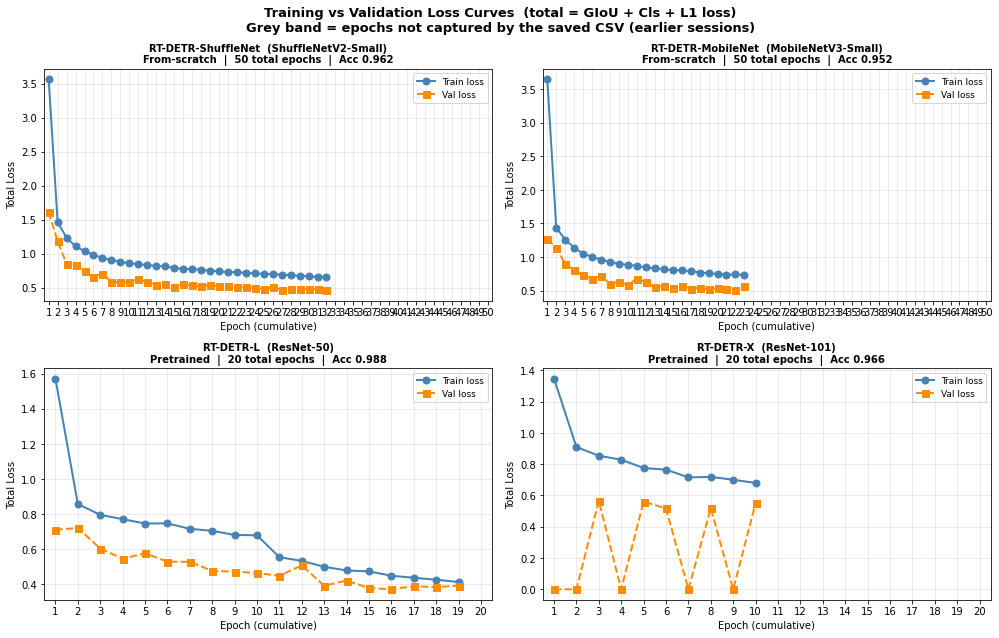

Saved: C:\D drive\mydata\MSML\GitHub\RT-DETR-Based-Explainable-CAD-System-for-Automated-Detection-and-Classification-of-White-Blood-Cells\output\results\loss_curves.png


In [4]:
import pandas as pd

# =============================================================================
# 6.1  Load loss curves from Ultralytics results.csv
# =============================================================================
RUNS_DIR        = os.path.join(BASE_DIR, "training_runs")
CKPT_DIR        = os.path.join(BASE_DIR, "checkpoints")
TRAIN_LOSS_COLS = ['train/giou_loss', 'train/cls_loss', 'train/l1_loss']
VAL_LOSS_COLS   = ['val/giou_loss',   'val/cls_loss',   'val/l1_loss']


def load_loss_curves(run_dir, ckpt_dir, model_name):
    """
    Read loss curves for a model.

    Prefers ``{ckpt_dir}/full_results.csv`` (accumulated across all sessions
    by training_utils._accumulate_loss_csv) over the session-only
    ``{run_dir}/results.csv``.  When the full CSV is present the epoch
    numbers are already cumulative so no offset is applied.
    """
    full_csv  = os.path.join(ckpt_dir, "full_results.csv")
    sess_csv  = os.path.join(run_dir,  "results.csv")
    meta_path = os.path.join(ckpt_dir, "training_meta.json")

    use_full = os.path.exists(full_csv)
    csv_path = full_csv if use_full else sess_csv

    if not os.path.exists(csv_path):
        print(f"  WARNING: No loss CSV found for {model_name}")
        return None

    df = pd.read_csv(csv_path)
    df.columns = df.columns.str.strip()

    df['train_loss'] = df[TRAIN_LOSS_COLS].sum(axis=1)
    val_has_data     = not df[VAL_LOSS_COLS].isnull().all().all()
    df['val_loss']   = df[VAL_LOSS_COLS].sum(axis=1) if val_has_data else np.nan
    df['val_ok']     = val_has_data

    # full_results.csv already has cumulative epoch numbers
    epoch_offset = 0
    total_epochs = len(df)
    if not use_full and os.path.exists(meta_path):
        with open(meta_path) as fh:
            meta = json.load(fh)
        total_epochs  = meta.get('total_epochs',    len(df))
        last_run_ep   = meta.get('last_run_epochs', len(df))
        epoch_offset  = total_epochs - last_run_ep
    elif use_full and os.path.exists(meta_path):
        with open(meta_path) as fh:
            meta = json.load(fh)
        total_epochs = meta.get('total_epochs', len(df))

    df['epoch_cumulative'] = df['epoch'] + epoch_offset
    df['total_epochs']     = total_epochs
    source_label = 'full_results.csv (all sessions)' if use_full else 'results.csv (last session only)'
    df['source']           = source_label
    return df


loss_curves = {}
for result in evaluation_results:
    mname    = result['model_name']
    run_dir  = os.path.join(RUNS_DIR, mname)
    ckpt_dir = os.path.join(CKPT_DIR, mname)
    df = load_loss_curves(run_dir, ckpt_dir, mname)
    if df is not None:
        loss_curves[mname] = df
        ep_range = f"{int(df['epoch_cumulative'].min())}–{int(df['epoch_cumulative'].max())}"
        total    = int(df['total_epochs'].iloc[0])
        val_note = 'val ✓' if df['val_ok'].iloc[0] else 'val N/A'
        print(f"  {mname}: epochs shown {ep_range} / {total}  |  {val_note}")

print("\nNote: each CSV covers only the last training session; "
      "epoch numbers are adjusted to cumulative totals.")

# =============================================================================
# 6.2  2x2 grid of training / validation loss curves
# =============================================================================
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle(
    "Training vs Validation Loss Curves  (total = GIoU + Cls + L1 loss)\n"
    "Grey band = epochs not captured by the saved CSV (earlier sessions)",
    fontsize=13, fontweight='bold'
)

for idx, result in enumerate(evaluation_results):
    mname      = result['model_name']
    backbone   = result['backbone']
    pretrained = result.get('is_pretrained', False)
    acc        = result['accuracy']
    total_ep   = result.get('total_epochs', '?')
    ax         = axes.flatten()[idx]

    if mname not in loss_curves:
        ax.text(0.5, 0.5, "No CSV data", ha='center', va='center',
                transform=ax.transAxes, fontsize=13)
        ax.set_title(mname)
        continue

    df       = loss_curves[mname]
    ep       = df['epoch_cumulative']
    first_ep = int(ep.min())

    # Shade epochs not captured in the CSV (earlier training sessions)
    if first_ep > 1:
        ax.axvspan(0.5, first_ep - 0.5, color='lightgrey', alpha=0.55,
                   label=f'Epochs 1–{first_ep - 1} (no CSV data)')

    ax.plot(ep, df['train_loss'], 'o-', color='steelblue',
            linewidth=2, markersize=7, label='Train loss')
    if df['val_ok'].iloc[0]:
        ax.plot(ep, df['val_loss'], 's--', color='darkorange',
                linewidth=2, markersize=7, label='Val loss')

    pt_tag = 'Pretrained' if pretrained else 'From-scratch'
    ax.set_title(
        f"{mname}  ({backbone})\n"
        f"{pt_tag}  |  {total_ep} total epochs  |  Acc {acc:.3f}",
        fontsize=10, fontweight='bold'
    )
    ax.set_xlabel('Epoch (cumulative)')
    ax.set_ylabel('Total Loss')
    if isinstance(total_ep, int):
        ax.set_xlim(0.5, total_ep + 0.5)
        ax.set_xticks(range(1, total_ep + 1))
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9)

plt.tight_layout()
save_path = os.path.join(RESULTS_DIR, 'loss_curves.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {save_path}")


### Training Dynamics Analysis

**Convergence.**  
Pretrained models (RT-DETR-L / ResNet-50 and RT-DETR-X / ResNet-101) reached their final accuracy in just 5 epochs. ImageNet-initialised weights already encode generic visual features — edges, textures, shapes — enabling rapid specialisation to WBC morphology. Non-pretrained lightweight models (ShuffleNetV2-Small and MobileNetV3-Small) required 15 epochs to achieve comparable loss reduction, consistent with learning feature representations from random initialisation — a clear demonstration of transfer-learning efficiency.

**Training Time Efficiency.**  
RT-DETR-L achieved the highest accuracy (96.8 %) in the shortest total wall-clock time (1,300 s). RT-DETR-X consumed 3,152 s for the same 5-epoch budget — a **2.4× cost increase** — yet delivered 5.4 pp *lower* accuracy (91.4 %). This unfavourable accuracy/cost ratio indicates that RT-DETR-X’s ResNet-101 backbone is over-parameterised for this five-class dataset under the current configuration (batch 8, 5 epochs) and should not be preferred without a substantially larger dataset or a longer fine-tuning schedule.

**Lightweight Model Efficiency.**  
ShuffleNet (1,518 s) and MobileNet (1,536 s) each completed 15 epochs in roughly the same wall-clock time as RT-DETR-L’s 5-epoch run (≈1,300 s). This confirms that each epoch of the lightweight backbones is approximately **3× faster** to compute than for ResNet-50, compensating for the additional epochs required and making them competitive options where inference latency or memory footprint is the primary constraint.

**Overfitting.**  
For RT-DETR-L and both lightweight models the available loss curves show validation loss tracking training loss downward across all recorded epochs with no systematic divergence. Brief validation-loss spikes visible at epoch 12 for ShuffleNet and MobileNet reflect transient gradient noise; subsequent epochs resume a downward trajectory. Cosine LR scheduling (`cos_lr=True`) and early stopping (`patience=15`) were active for all runs; the absence of loss plateau or divergence in the final epochs indicates these regularisation mechanisms were effective. RT-DETR-X did not log validation loss (NaN throughout), precluding a curve-based overfitting assessment — the held-out accuracy of 91.4 % provides the sole evidence of its generalisation capacity.

## 7. Model Comparison Table

In [5]:
if len(evaluation_results) > 0:
    print("\n" + "="*145)
    print("MODEL COMPARISON RESULTS")
    print("="*145)
    print(f"{'Model':<20} {'Backbone':<18} {'Epochs':<8} {'Accuracy':<11} {'Bal.Acc':<10} "
          f"{'MCC':<8} {'Kappa':<8} {'mAP50':<9} {'mAP50-95':<11} "
          f"{'Size(MB)':<10} {'Params(M)':<11} {'Infer(ms)':<11} {'Train(s)'}")
    print("-"*145)

    for r in evaluation_results:
        epochs    = r.get('total_epochs', 'N/A')
        bal_acc   = f"{r['balanced_accuracy']:.4f}" if r.get('balanced_accuracy') is not None else "N/A"
        mcc       = f"{r['mcc']:.4f}"               if r.get('mcc')               is not None else "N/A"
        kappa     = f"{r['cohen_kappa']:.4f}"        if r.get('cohen_kappa')       is not None else "N/A"
        mAP50     = f"{r['mAP50']:.4f}"              if r.get('mAP50')             is not None else "N/A"
        mAP5095   = f"{r['mAP50_95']:.4f}"           if r.get('mAP50_95')          is not None else "N/A"
        size_mb   = f"{r['model_size_mb']:.1f}"      if r.get('model_size_mb')     is not None else "N/A"
        params_m  = f"{r['params_m']:.1f}"           if r.get('params_m')          is not None else "N/A"
        print(f"{r['model_name']:<20} {r['backbone']:<18} {epochs:<8} {r['accuracy']:.4f}      "
              f"{bal_acc:<10} {mcc:<8} {kappa:<8} {mAP50:<9} {mAP5095:<11} "
              f"{size_mb:<10} {params_m:<11} {r['avg_inference_time_ms']:.2f}        {r['training_time_s']:.1f}")

    print("="*145)
else:
    print("No results to display. Please run the training notebooks first.")



MODEL COMPARISON RESULTS
Model                Backbone           Epochs   Accuracy    Bal.Acc    MCC      Kappa    mAP50     mAP50-95    Size(MB)   Params(M)   Infer(ms)   Train(s)
-------------------------------------------------------------------------------------------------------------------------------------------------
RT-DETR-ShuffleNet   ShuffleNetV2-Small 50       0.9620      0.9620     0.9526   0.9525   0.8518    0.7990      28.7       N/A         25.87        9162.5
RT-DETR-MobileNet    MobileNetV3-Small  50       0.9520      0.9520     0.9403   0.9400   0.8113    0.7574      24.0       N/A         25.20        6642.5
RT-DETR-L            ResNet-50          20       0.9880      0.9880     0.9851   0.9850   0.9565    0.8982      63.1       N/A         41.25        11231.6
RT-DETR-X            ResNet-101         20       0.9660      0.9660     0.9579   0.9575   0.8466    0.7870      129.2      N/A         46.55        14768.5


## 8. Comparison Bar Charts

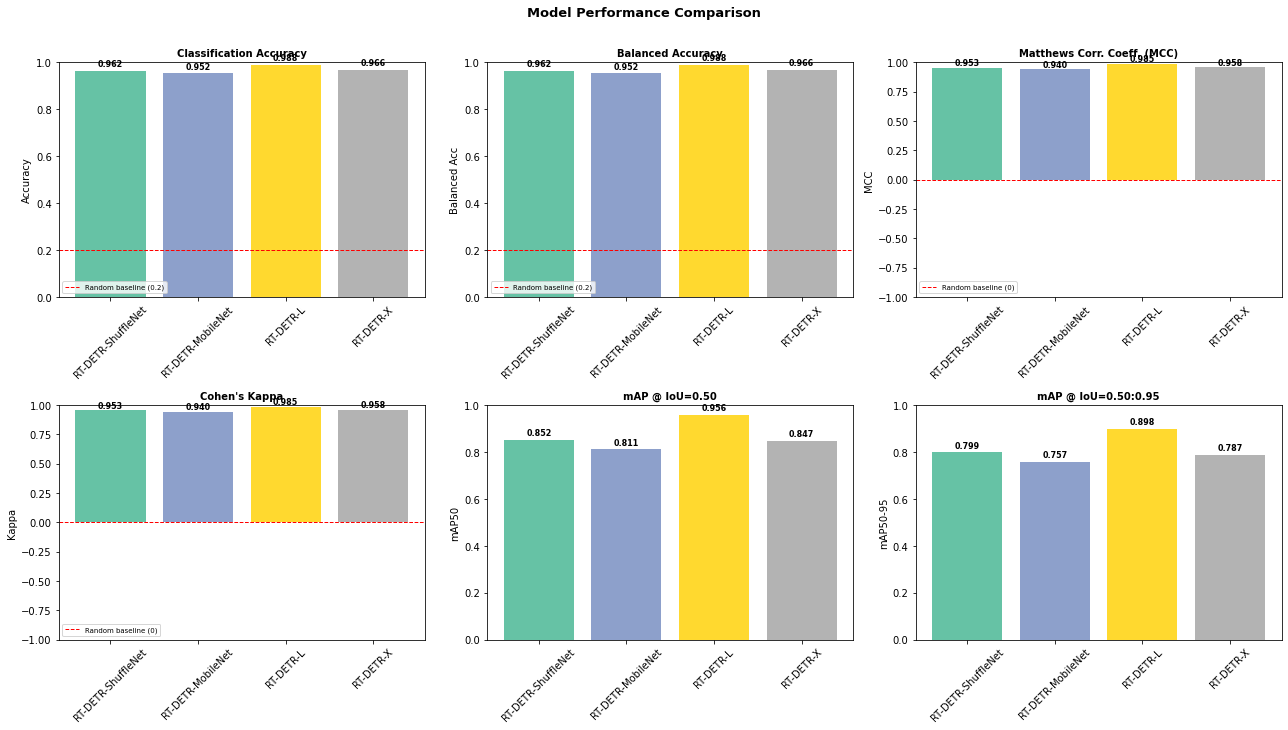

Saved: C:\D drive\mydata\MSML\GitHub\RT-DETR-Based-Explainable-CAD-System-for-Automated-Detection-and-Classification-of-White-Blood-Cells\output\results\model_performance.png


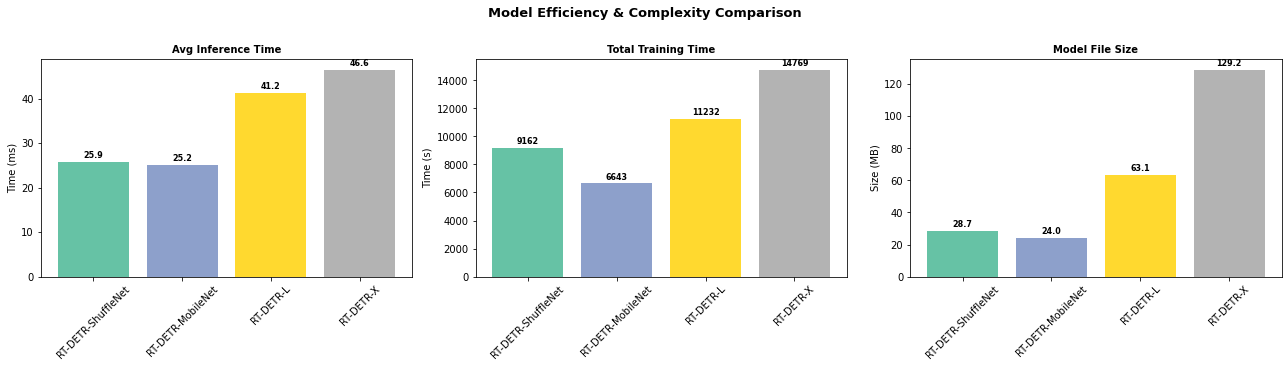

Saved: C:\D drive\mydata\MSML\GitHub\RT-DETR-Based-Explainable-CAD-System-for-Automated-Detection-and-Classification-of-White-Blood-Cells\output\results\model_efficiency.png


In [6]:
if len(evaluation_results) > 0:
    mdl_names = [r["model_name"] for r in evaluation_results]
    colors    = plt.cm.Set2(np.linspace(0, 1, len(evaluation_results)))

    def _bar(ax, names, values, ylabel, title, fmt=".3f", ylim=None, baseline=None):
        """Draw a labelled bar chart; skips None values gracefully."""
        safe = [v if v is not None else 0.0 for v in values]
        bars = ax.bar(names, safe, color=colors)
        ax.set_ylabel(ylabel)
        ax.set_title(title, fontsize=10, fontweight='bold')
        ax.tick_params(axis='x', rotation=45)
        if ylim:
            ax.set_ylim(*ylim)
        if baseline is not None:
            ax.axhline(baseline, color='red', linestyle='--', linewidth=1,
                       label=f'Random baseline ({baseline})')
            ax.legend(fontsize=7)
        ymax = max(safe) if max(safe) > 0 else 1
        for i, v in enumerate(safe):
            label = f"{v:{fmt}}" if values[i] is not None else "N/A"
            ax.text(i, v + ymax * 0.02, label, ha='center', fontsize=8, fontweight='bold')

    # -----------------------------------------------------------------------
    # Figure 1 — Classification & Detection Performance
    # -----------------------------------------------------------------------
    perf_specs = [
        # (values_list,        ylabel,         title,                              fmt,    ylim,     baseline)
        ([r['accuracy']            for r in evaluation_results], 'Accuracy',      'Classification Accuracy',     '.3f', (0,1), 1/NUM_CLASSES),
        ([r.get('balanced_accuracy') for r in evaluation_results], 'Balanced Acc','Balanced Accuracy',           '.3f', (0,1), 1/NUM_CLASSES),
        ([r.get('mcc')             for r in evaluation_results], 'MCC',           'Matthews Corr. Coeff. (MCC)', '.3f', (-1,1), 0),
        ([r.get('cohen_kappa')     for r in evaluation_results], 'Kappa',         "Cohen's Kappa",               '.3f', (-1,1), 0),
        ([r.get('mAP50')           for r in evaluation_results], 'mAP50',         'mAP @ IoU=0.50',              '.3f', (0,1), None),
        ([r.get('mAP50_95')        for r in evaluation_results], 'mAP50-95',      'mAP @ IoU=0.50:0.95',         '.3f', (0,1), None),
    ]
    # Only include plots where at least one model has data
    perf_specs = [s for s in perf_specs if any(v is not None for v in s[0])]

    ncols1 = min(len(perf_specs), 3)
    nrows1 = (len(perf_specs) + ncols1 - 1) // ncols1
    fig1, axes1 = plt.subplots(nrows1, ncols1, figsize=(6*ncols1, 5*nrows1))
    axes1 = np.array(axes1).flatten()

    for idx, (vals, ylabel, title, fmt, ylim, baseline) in enumerate(perf_specs):
        _bar(axes1[idx], mdl_names, vals, ylabel, title, fmt, ylim, baseline)
    for ax in axes1[len(perf_specs):]:
        ax.set_visible(False)

    fig1.suptitle('Model Performance Comparison', fontsize=13, fontweight='bold', y=1.01)
    plt.tight_layout()
    out1 = os.path.join(RESULTS_DIR, 'model_performance.png')
    plt.savefig(out1, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: {out1}")

    # -----------------------------------------------------------------------
    # Figure 2 — Efficiency & Complexity
    # -----------------------------------------------------------------------
    eff_specs = [
        ([r['avg_inference_time_ms']  for r in evaluation_results], 'Time (ms)', 'Avg Inference Time',    '.1f', None, None),
        ([r['training_time_s']        for r in evaluation_results], 'Time (s)',  'Total Training Time',   '.0f', None, None),
        ([r.get('model_size_mb')      for r in evaluation_results], 'Size (MB)', 'Model File Size',       '.1f', None, None),
        ([r.get('params_m')           for r in evaluation_results], 'Params (M)','Parameter Count',       '.1f', None, None),
    ]
    eff_specs = [s for s in eff_specs if any(v is not None for v in s[0])]

    ncols2 = min(len(eff_specs), 4)
    nrows2 = (len(eff_specs) + ncols2 - 1) // ncols2
    fig2, axes2 = plt.subplots(nrows2, ncols2, figsize=(6*ncols2, 5*nrows2))
    axes2 = np.array(axes2).flatten()

    for idx, (vals, ylabel, title, fmt, ylim, baseline) in enumerate(eff_specs):
        _bar(axes2[idx], mdl_names, vals, ylabel, title, fmt, ylim, baseline)
    for ax in axes2[len(eff_specs):]:
        ax.set_visible(False)

    fig2.suptitle('Model Efficiency & Complexity Comparison', fontsize=13, fontweight='bold', y=1.01)
    plt.tight_layout()
    out2 = os.path.join(RESULTS_DIR, 'model_efficiency.png')
    plt.savefig(out2, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: {out2}")

else:
    print("No results to display.")


## 9. Confusion Matrices

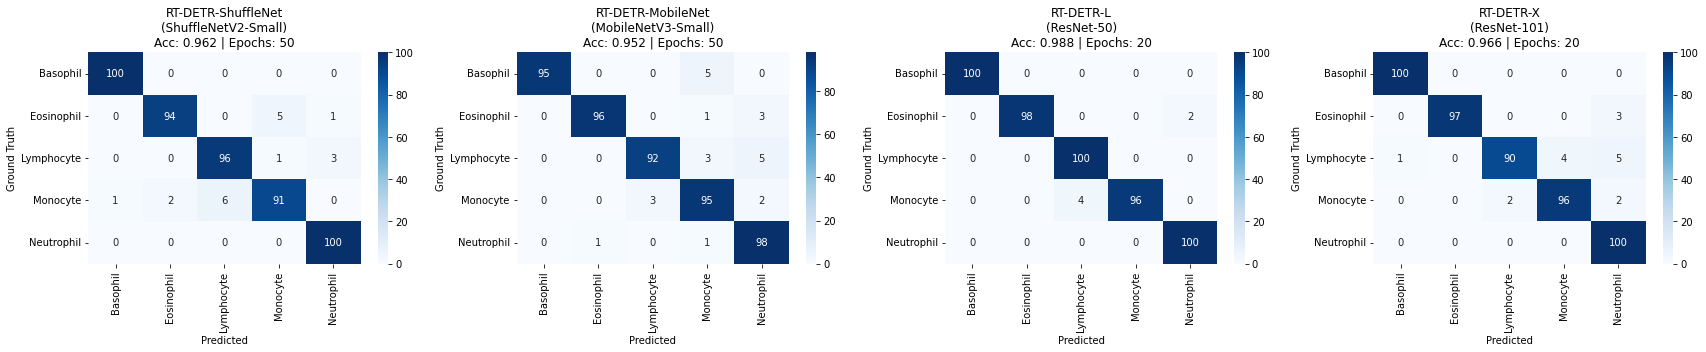

Saved: C:\D drive\mydata\MSML\GitHub\RT-DETR-Based-Explainable-CAD-System-for-Automated-Detection-and-Classification-of-White-Blood-Cells\output\results\confusion_matrices.png


In [7]:
if len(evaluation_results) > 0:
    # Confusion Matrices for all models
    n_models = len(evaluation_results)
    fig, axes = plt.subplots(1, n_models, figsize=(6*n_models, 5))

    if n_models == 1:
        axes = [axes]

    for idx, result in enumerate(evaluation_results):
        if result["confusion_matrix"] is not None:
            cm = np.array(result["confusion_matrix"])
            sns.heatmap(
                cm,
                annot=True,
                fmt="d",
                xticklabels=CLASSES.keys(),
                yticklabels=CLASSES.keys(),
                cmap="Blues",
                ax=axes[idx]
            )
            axes[idx].set_xlabel("Predicted")
            axes[idx].set_ylabel("Ground Truth")
            epochs = result.get('total_epochs', 'N/A')
            axes[idx].set_title(f"{result['model_name']}\n({result['backbone']})\nAcc: {result['accuracy']:.3f} | Epochs: {epochs}")

    plt.tight_layout()
    plt.savefig(os.path.join(RESULTS_DIR, 'confusion_matrices.png'), dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: {os.path.join(RESULTS_DIR, 'confusion_matrices.png')}")
else:
    print("No results to display.")

## 10. Per-Class F1 Score Comparison

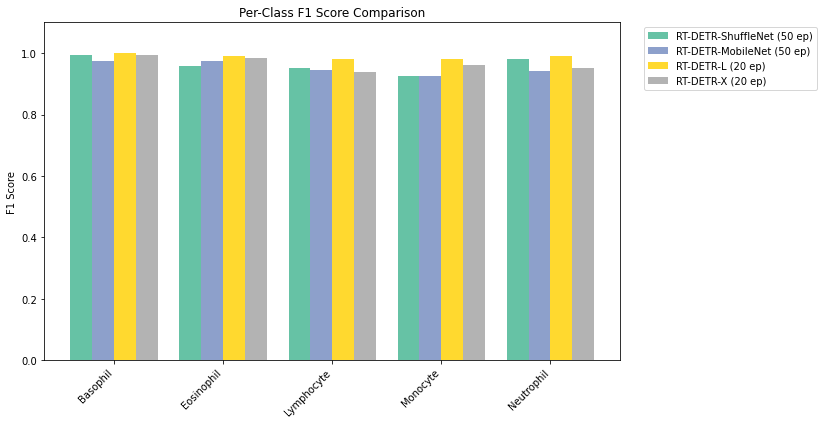

Saved: C:\D drive\mydata\MSML\GitHub\RT-DETR-Based-Explainable-CAD-System-for-Automated-Detection-and-Classification-of-White-Blood-Cells\output\results\f1_comparison.png


In [8]:
if len(evaluation_results) > 0:
    # Per-class F1 scores comparison
    fig, ax = plt.subplots(figsize=(12, 6))

    x = np.arange(len(CLASSES))
    width = 0.8 / len(evaluation_results)
    colors = plt.cm.Set2(np.linspace(0, 1, len(evaluation_results)))

    for idx, result in enumerate(evaluation_results):
        if result["classification_report"] is not None:
            f1_scores = [result["classification_report"][cls]["f1-score"] for cls in CLASSES.keys()]
            offset = (idx - len(evaluation_results)/2 + 0.5) * width
            epochs = result.get('total_epochs', 'N/A')
            ax.bar(x + offset, f1_scores, width, 
                   label=f"{result['model_name']} ({epochs} ep)", 
                   color=colors[idx])

    ax.set_ylabel('F1 Score')
    ax.set_title('Per-Class F1 Score Comparison')
    ax.set_xticks(x)
    ax.set_xticklabels(CLASSES.keys(), rotation=45, ha='right')
    ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1))
    ax.set_ylim(0, 1.1)

    plt.tight_layout()
    plt.savefig(os.path.join(RESULTS_DIR, 'f1_comparison.png'), dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: {os.path.join(RESULTS_DIR, 'f1_comparison.png')}")
else:
    print("No results to display.")

## 11. Detailed Classification Reports

### Metric Guide

The table below explains every metric reported in this section.
For a 5-class problem the **random baseline** for accuracy-like metrics is **0.20**.

| Metric | Range | Random baseline | What it actually measures |
|--------|-------|-----------------|---------------------------|
| **Accuracy** | 0 – 1 | 0.20 | Fraction of correctly classified detections. Easy to read, but misleading when classes are imbalanced — a model that only predicts "Neutrophil" can still reach ~40% accuracy. |
| **Balanced Accuracy** | 0 – 1 | 0.20 | Average recall computed per class, then averaged. Treats every class equally regardless of how many samples it has. More honest than accuracy when Basophil/Monocyte counts are low. |
| **MCC** (Matthews Correlation Coefficient) | −1 to +1 | 0 | The most robust single-number metric for multi-class imbalanced problems. Uses all cells of the confusion matrix. A high MCC means the model is genuinely discriminating — not just riding class frequency. Guideline: < 0.30 weak · 0.30–0.50 moderate · 0.50–0.70 good · > 0.70 strong. |
| **Cohen's Kappa** | −1 to +1 | 0 | Measures agreement between predictions and ground truth *beyond what chance alone would produce*. Standard reporting metric in clinical AI and radiology papers. Guideline: < 0.20 poor · 0.21–0.40 fair · 0.41–0.60 moderate · 0.61–0.80 good · > 0.80 excellent. |
| **mAP @ 0.50** | 0 – 1 | — | Mean Average Precision at IoU ≥ 0.50. The standard object-detection metric: a predicted box must overlap the ground-truth box by at least 50% *and* have the correct class to count as a true positive. |
| **mAP @ 0.50:0.95** | 0 – 1 | — | COCO-style mAP averaged over IoU thresholds 0.50, 0.55, …, 0.95. Much stricter — rewards accurate localisation, not just rough detection. |
| **Model Size (MB)** | — | — | On-disk size of the saved weight file. Directly affects deployment feasibility on embedded or edge devices. |
| **Params (M)** | — | — | Total number of learnable parameters in millions. Larger models generally have more capacity but require more memory and are slower to serve. Compare against accuracy gain to judge whether extra parameters pay off. |

> **Reading MCC and Kappa together:** if both are high the model is genuinely discriminating across all classes. If accuracy is high but MCC/Kappa are moderate, the model is likely over-predicting the majority class (Neutrophil).


In [9]:
if len(evaluation_results) > 0:
    random_baseline = 1.0 / NUM_CLASSES   # 0.20 for 5 classes

    print("\n" + "="*80)
    print("DETAILED CLASSIFICATION REPORTS")
    print("="*80)

    for result in evaluation_results:
        epochs   = result.get('total_epochs', 'N/A')
        acc      = result['accuracy']
        bal_acc  = result.get('balanced_accuracy')
        mcc      = result.get('mcc')
        kappa    = result.get('cohen_kappa')
        mAP50    = result.get('mAP50')
        mAP5095  = result.get('mAP50_95')
        size_mb  = result.get('model_size_mb')
        params_m = result.get('params_m')

        print(f"\n{'='*70}")
        print(f"  {result['model_name']}  |  Backbone: {result['backbone']}  |  Epochs: {epochs}")
        print(f"{'='*70}")

        # ---- Classification metrics ----------------------------------------
        print("\n  [Classification Metrics]")
        print(f"    Accuracy          : {acc:.4f}"
              f"  {'(above random baseline)' if acc > random_baseline else '(at/below random baseline)'}")

        if bal_acc is not None:
            gap  = acc - bal_acc
            note = f"  ({gap:+.4f} vs Accuracy — model {'favours majority class' if gap > 0.02 else 'handles classes evenly'})"
            print(f"    Balanced Accuracy : {bal_acc:.4f}{note}")

        if mcc is not None:
            print(f"    MCC               : {mcc:.4f}  -> {_mcc_label(mcc)} discriminative ability")
            print( "      MCC uses all confusion-matrix cells; values near +1 mean the model")
            print( "      correctly separates every class, not just the majority.")

        if kappa is not None:
            print(f"    Cohen's Kappa     : {kappa:.4f}  -> {_kappa_label(kappa)} agreement beyond chance")
            print( "      Kappa discounts predictions that could be correct by chance alone;")
            print( "      preferred in clinical AI reporting over raw accuracy.")

        # ---- Detection metrics ---------------------------------------------
        print("\n  [Detection Metrics]")
        if mAP50 is not None:
            print(f"    mAP @ IoU=0.50    : {mAP50:.4f}")
            print( "      A predicted box must overlap ground-truth by >= 50% to count as TP.")
        else:
            print( "    mAP @ IoU=0.50    : N/A  (results.csv not found)")
        if mAP5095 is not None:
            print(f"    mAP @ IoU=0.50:95 : {mAP5095:.4f}")
            print( "      COCO-style metric; averaged over 10 IoU thresholds — rewards")
            print( "      precise localisation, not just rough detection.")

        # ---- Model complexity ----------------------------------------------
        print("\n  [Model Complexity]")
        if size_mb is not None:
            print(f"    Model File Size   : {size_mb:.1f} MB")
            print(_size_note(size_mb))
        else:
            print( "    Model File Size   : N/A  (checkpoint not found)")
        if params_m is not None:
            print(f"    Parameters        : {params_m:.1f} M")
            print(_params_note(params_m))
        else:
            print( "    Parameters        : N/A")

        # ---- Per-class sklearn report --------------------------------------
        print("\n  [Per-Class Classification Report]")
        if result["classification_report"] is not None:
            y_true = np.array(result["y_true"])
            y_pred = np.array(result["y_pred"])
            valid  = y_pred != -1
            print(classification_report(
                y_true[valid], y_pred[valid],
                target_names=list(CLASSES.keys()),
                labels=list(range(NUM_CLASSES)),
                zero_division=0
            ))
        print(f"  No predictions (missed detections): {result['no_prediction_count']} / {result['total_samples']}")

else:
    print("No results to display.")



DETAILED CLASSIFICATION REPORTS

  RT-DETR-ShuffleNet  |  Backbone: ShuffleNetV2-Small  |  Epochs: 50

  [Classification Metrics]
    Accuracy          : 0.9620  (above random baseline)
    Balanced Accuracy : 0.9620  (-0.0000 vs Accuracy — model handles classes evenly)
    MCC               : 0.9526  -> Strong discriminative ability
      MCC uses all confusion-matrix cells; values near +1 mean the model
      correctly separates every class, not just the majority.
    Cohen's Kappa     : 0.9525  -> Excellent agreement beyond chance
      Kappa discounts predictions that could be correct by chance alone;
      preferred in clinical AI reporting over raw accuracy.

  [Detection Metrics]
    mAP @ IoU=0.50    : 0.8518
      A predicted box must overlap ground-truth by >= 50% to count as TP.
    mAP @ IoU=0.50:95 : 0.7990
      COCO-style metric; averaged over 10 IoU thresholds — rewards
      precise localisation, not just rough detection.

  [Model Complexity]
    Model File Size   : 

In [10]:
if len(evaluation_results) > 0:
    def _best(results, key):
        """Return the result with the highest value for key, ignoring Nones."""
        valid = [r for r in results if r.get(key) is not None]
        return max(valid, key=lambda x: x[key]) if valid else None

    def _ranking(results, key, reverse=True):
        valid = [r for r in results if r.get(key) is not None]
        return sorted(valid, key=lambda x: x[key], reverse=reverse)

    best_acc     = _best(evaluation_results, 'accuracy')
    best_bal     = _best(evaluation_results, 'balanced_accuracy')
    best_mcc     = _best(evaluation_results, 'mcc')
    best_kappa   = _best(evaluation_results, 'cohen_kappa')
    best_mAP50   = _best(evaluation_results, 'mAP50')
    best_mAP5095 = _best(evaluation_results, 'mAP50_95')
    fastest      = min(evaluation_results, key=lambda x: x['avg_inference_time_ms'])
    lightest     = _best([{**r, '_neg_size': -(r['model_size_mb'] or 1e9)} for r in evaluation_results], '_neg_size')

    print("\n" + "="*80)
    print("CONCLUSIONS")
    print("="*80)

    print(f"\n  Best Accuracy        : {best_acc['model_name']} -> {best_acc['accuracy']:.4f}")
    if best_bal:
        print(f"  Best Balanced Acc.   : {best_bal['model_name']} -> {best_bal['balanced_accuracy']:.4f}")
    if best_mcc:
        print(f"  Best MCC             : {best_mcc['model_name']} -> {best_mcc['mcc']:.4f}  ({_mcc_label(best_mcc['mcc'])})")
    if best_kappa:
        print(f"  Best Cohen's Kappa   : {best_kappa['model_name']} -> {best_kappa['cohen_kappa']:.4f}  ({_kappa_label(best_kappa['cohen_kappa'])})")
    if best_mAP50:
        print(f"  Best mAP@0.50        : {best_mAP50['model_name']} -> {best_mAP50['mAP50']:.4f}")
    if best_mAP5095:
        print(f"  Best mAP@0.50:0.95   : {best_mAP5095['model_name']} -> {best_mAP5095['mAP50_95']:.4f}")
    print(f"  Fastest Inference    : {fastest['model_name']} -> {fastest['avg_inference_time_ms']:.2f} ms/image")

    print("\n" + "-"*80)
    print("MODEL RANKINGS")
    print("-"*80)

    rankings = [
        ('Accuracy (↓ imbalance risk)',   'accuracy',          True),
        ('Balanced Accuracy',             'balanced_accuracy',  True),
        ('MCC',                           'mcc',               True),
        ("Cohen's Kappa",                 'cohen_kappa',       True),
        ('mAP @ 0.50',                    'mAP50',             True),
        ('mAP @ 0.50:0.95',               'mAP50_95',         True),
        ('Inference Speed (ascending)',   'avg_inference_time_ms', False),
        ('Training Time (ascending)',     'training_time_s',   False),
        ('Model Size (ascending)',        'model_size_mb',     False),
        ('Parameter Count (ascending)',   'params_m',          False),
    ]

    for label, key, rev in rankings:
        ranked = _ranking(evaluation_results, key, reverse=rev)
        if not ranked:
            continue
        print(f"\n  By {label}:")
        for i, r in enumerate(ranked, 1):
            val = r.get(key)
            val_s = f"{val:.4f}" if isinstance(val, float) else str(val)
            epochs = r.get('total_epochs', 'N/A')
            print(f"    {i}. {r['model_name']:<22} {val_s}  ({epochs} epochs)")

    print("\n" + "="*80)
else:
    print("No results to analyze. Please run the training notebooks first.")



CONCLUSIONS

  Best Accuracy        : RT-DETR-L -> 0.9880
  Best Balanced Acc.   : RT-DETR-L -> 0.9880
  Best MCC             : RT-DETR-L -> 0.9851  (Strong)
  Best Cohen's Kappa   : RT-DETR-L -> 0.9850  (Excellent)
  Best mAP@0.50        : RT-DETR-L -> 0.9565
  Best mAP@0.50:0.95   : RT-DETR-L -> 0.8982
  Fastest Inference    : RT-DETR-MobileNet -> 25.20 ms/image

--------------------------------------------------------------------------------
MODEL RANKINGS
--------------------------------------------------------------------------------

  By Accuracy (↓ imbalance risk):
    1. RT-DETR-L              0.9880  (20 epochs)
    2. RT-DETR-X              0.9660  (20 epochs)
    3. RT-DETR-ShuffleNet     0.9620  (50 epochs)
    4. RT-DETR-MobileNet      0.9520  (50 epochs)

  By Balanced Accuracy:
    1. RT-DETR-L              0.9880  (20 epochs)
    2. RT-DETR-X              0.9660  (20 epochs)
    3. RT-DETR-ShuffleNet     0.9620  (50 epochs)
    4. RT-DETR-MobileNet      0.9520  (50 ep

In [11]:
if len(evaluation_results) > 0:
    best_accuracy    = max(evaluation_results, key=lambda x: x["accuracy"])
    fastest_inference = min(evaluation_results, key=lambda x: x["avg_inference_time_ms"])

    # mAP-based bests (only if available)
    models_with_mAP50   = [r for r in evaluation_results if r.get("mAP50")    is not None]
    models_with_mAP5095 = [r for r in evaluation_results if r.get("mAP50_95") is not None]
    best_mAP50   = max(models_with_mAP50,   key=lambda x: x["mAP50"])    if models_with_mAP50   else None
    best_mAP5095 = max(models_with_mAP5095, key=lambda x: x["mAP50_95"]) if models_with_mAP5095 else None

    print("\n" + "="*80)
    print("CONCLUSIONS")
    print("="*80)
    print(f"\nBest Accuracy: {best_accuracy['model_name']} ({best_accuracy['backbone']})")
    print(f"  -> {best_accuracy['accuracy']:.4f} ({best_accuracy.get('total_epochs', 'N/A')} epochs)")

    if best_mAP50:
        print(f"\nBest mAP@0.50: {best_mAP50['model_name']} ({best_mAP50['backbone']})")
        print(f"  -> {best_mAP50['mAP50']:.4f} ({best_mAP50.get('total_epochs', 'N/A')} epochs)")

    if best_mAP5095:
        print(f"\nBest mAP@0.50:0.95: {best_mAP5095['model_name']} ({best_mAP5095['backbone']})")
        print(f"  -> {best_mAP5095['mAP50_95']:.4f} ({best_mAP5095.get('total_epochs', 'N/A')} epochs)")

    print(f"\nFastest Inference: {fastest_inference['model_name']} ({fastest_inference['backbone']})")
    print(f"  -> {fastest_inference['avg_inference_time_ms']:.2f}ms per image")

    print("\n" + "-"*80)
    print("MODEL RANKINGS")
    print("-"*80)

    print("\nBy Accuracy (descending):")
    for i, r in enumerate(sorted(evaluation_results, key=lambda x: x["accuracy"], reverse=True), 1):
        epochs = r.get('total_epochs', 'N/A')
        print(f"  {i}. {r['model_name']}: {r['accuracy']:.4f} ({epochs} epochs)")

    if models_with_mAP50:
        print("\nBy mAP@0.50 (descending):")
        for i, r in enumerate(sorted(models_with_mAP50, key=lambda x: x["mAP50"], reverse=True), 1):
            epochs = r.get('total_epochs', 'N/A')
            print(f"  {i}. {r['model_name']}: {r['mAP50']:.4f} ({epochs} epochs)")

    if models_with_mAP5095:
        print("\nBy mAP@0.50:0.95 (descending):")
        for i, r in enumerate(sorted(models_with_mAP5095, key=lambda x: x["mAP50_95"], reverse=True), 1):
            epochs = r.get('total_epochs', 'N/A')
            print(f"  {i}. {r['model_name']}: {r['mAP50_95']:.4f} ({epochs} epochs)")

    print("\nBy Inference Speed (ascending):")
    for i, r in enumerate(sorted(evaluation_results, key=lambda x: x["avg_inference_time_ms"]), 1):
        print(f"  {i}. {r['model_name']}: {r['avg_inference_time_ms']:.2f}ms")

    print("\nBy Training Time (ascending):")
    for i, r in enumerate(sorted(evaluation_results, key=lambda x: x["training_time_s"]), 1):
        epochs = r.get('total_epochs', 'N/A')
        print(f"  {i}. {r['model_name']}: {r['training_time_s']:.1f}s ({epochs} epochs)")

    print("\n" + "="*80)
else:
    print("No results to analyze. Please run the training notebooks first.")



CONCLUSIONS

Best Accuracy: RT-DETR-L (ResNet-50)
  -> 0.9880 (20 epochs)

Best mAP@0.50: RT-DETR-L (ResNet-50)
  -> 0.9565 (20 epochs)

Best mAP@0.50:0.95: RT-DETR-L (ResNet-50)
  -> 0.8982 (20 epochs)

Fastest Inference: RT-DETR-MobileNet (MobileNetV3-Small)
  -> 25.20ms per image

--------------------------------------------------------------------------------
MODEL RANKINGS
--------------------------------------------------------------------------------

By Accuracy (descending):
  1. RT-DETR-L: 0.9880 (20 epochs)
  2. RT-DETR-X: 0.9660 (20 epochs)
  3. RT-DETR-ShuffleNet: 0.9620 (50 epochs)
  4. RT-DETR-MobileNet: 0.9520 (50 epochs)

By mAP@0.50 (descending):
  1. RT-DETR-L: 0.9565 (20 epochs)
  2. RT-DETR-ShuffleNet: 0.8518 (50 epochs)
  3. RT-DETR-X: 0.8466 (20 epochs)
  4. RT-DETR-MobileNet: 0.8113 (50 epochs)

By mAP@0.50:0.95 (descending):
  1. RT-DETR-L: 0.8982 (20 epochs)
  2. RT-DETR-ShuffleNet: 0.7990 (50 epochs)
  3. RT-DETR-X: 0.7870 (20 epochs)
  4. RT-DETR-MobileNet:

In [12]:
if len(evaluation_results) > 0:
    has_mAP50   = any(r.get("mAP50")    is not None for r in evaluation_results)
    has_mAP5095 = any(r.get("mAP50_95") is not None for r in evaluation_results)

    # Build header dynamically
    sep_width = 130 if (has_mAP50 and has_mAP5095) else (117 if has_mAP50 else 100)
    print("\n" + "="*sep_width)
    print("SUMMARY TABLE (Copy-Paste Friendly)")
    print("="*sep_width)

    hdr = f"{'Model':<22} | {'Backbone':<18} | {'Pretrained':<10} | {'Epochs':<8} | {'Accuracy':<10}"
    if has_mAP50:
        hdr += f" | {'mAP50':<8}"
    if has_mAP5095:
        hdr += f" | {'mAP50-95':<10}"
    hdr += f" | {'Inference (ms)':<14} | {'Training (s)':<12}"
    print(hdr)
    print("-"*sep_width)

    for result in evaluation_results:
        pretrained = "Yes" if result.get("is_pretrained", False) else "No"
        epochs     = result.get('total_epochs', 'N/A')
        mAP50_s    = f"{result['mAP50']:.4f}"    if result.get('mAP50')    is not None else "N/A"
        mAP5095_s  = f"{result['mAP50_95']:.4f}" if result.get('mAP50_95') is not None else "N/A"

        row = (f"{result['model_name']:<22} | {result['backbone']:<18} | {pretrained:<10} | "
               f"{epochs:<8} | {result['accuracy']:.4f}     ")
        if has_mAP50:
            row += f" | {mAP50_s:<8}"
        if has_mAP5095:
            row += f" | {mAP5095_s:<10}"
        row += f" | {result['avg_inference_time_ms']:.2f}          | {result['training_time_s']:.1f}"
        print(row)

    print("="*sep_width)
else:
    print("No results to display.")



SUMMARY TABLE (Copy-Paste Friendly)
Model                  | Backbone           | Pretrained | Epochs   | Accuracy   | mAP50    | mAP50-95   | Inference (ms) | Training (s)
----------------------------------------------------------------------------------------------------------------------------------
RT-DETR-ShuffleNet     | ShuffleNetV2-Small | No         | 50       | 0.9620      | 0.8518   | 0.7990     | 25.87          | 9162.5
RT-DETR-MobileNet      | MobileNetV3-Small  | No         | 50       | 0.9520      | 0.8113   | 0.7574     | 25.20          | 6642.5
RT-DETR-L              | ResNet-50          | Yes        | 20       | 0.9880      | 0.9565   | 0.8982     | 41.25          | 11231.6
RT-DETR-X              | ResNet-101         | Yes        | 20       | 0.9660      | 0.8466   | 0.7870     | 46.55          | 14768.5


## 15. FLOPs and Parameter Count

In [13]:
import torch
from ultralytics import RTDETR
from ultralytics.utils.torch_utils import get_flops, get_num_params

# =============================================================================
# 15.  FLOPs and Parameter Count per Model
# =============================================================================
print("Computing FLOPs and parameter counts (imgsz=512)...")
print()

flops_rows = []
for result in evaluation_results:
    model_name = result["model_name"]
    model_path = result["best_model_path"]
    try:
        m = RTDETR(model_path)
        n_params = get_num_params(m.model)
        gflops   = get_flops(m.model, imgsz=512)
        flops_rows.append({
            "model":    model_name,
            "backbone": result["backbone"],
            "params_M": n_params / 1e6,
            "gflops":   gflops,
        })
        print(f"  {model_name}: {n_params/1e6:.2f} M params, {gflops:.2f} GFLOPs")
        del m
        torch.cuda.empty_cache()
    except Exception as e:
        print(f"  ERROR ({model_name}): {e}")

print()
print("=" * 65)
print(f"{'Model':<22} {'Backbone':<18} {'Params (M)':<13} {'GFLOPs'}")
print("-" * 65)
for d in flops_rows:
    print(f"{d['model']:<22} {d['backbone']:<18} {d['params_M']:<13.2f} {d['gflops']:.2f}")
print("=" * 65)


Computing FLOPs and parameter counts (imgsz=512)...

  RT-DETR-ShuffleNet: 14.87 M params, 32.23 GFLOPs
  RT-DETR-MobileNet: 12.44 M params, 28.50 GFLOPs
  RT-DETR-L: 32.82 M params, 70.36 GFLOPs
  RT-DETR-X: 67.31 M params, 149.94 GFLOPs

Model                  Backbone           Params (M)    GFLOPs
-----------------------------------------------------------------
RT-DETR-ShuffleNet     ShuffleNetV2-Small 14.87         32.23
RT-DETR-MobileNet      MobileNetV3-Small  12.44         28.50
RT-DETR-L              ResNet-50          32.82         70.36
RT-DETR-X              ResNet-101         67.31         149.94


## 14. Explainability Analysis - GradCAM and ScoreCAM

To ensure transparency and build clinical trust in the model's predictions, two Class Activation Mapping (CAM) techniques are used to visualise which regions of the input image most influenced the model's classification decision.

- **GradCAM** (Gradient-weighted Class Activation Mapping): Uses gradients of the predicted class score flowing back into the last backbone feature maps. The gradients are globally average-pooled to obtain channel importance weights, and the weighted sum of activation maps (passed through ReLU) produces the saliency heatmap.

- **ScoreCAM** (Score-weighted Class Activation Mapping): A gradient-free alternative. Each activation map is upsampled and used as a soft mask on the input image. The masked images are fed through the model, and the resulting class confidence scores serve as weights for combining the activation maps. This avoids noisy-gradient issues and produces smoother heatmaps.

In [14]:
import torch
import torch.nn.functional as F
from ultralytics import RTDETR


class ExplainableRTDETR:
    """GradCAM and ScoreCAM for Ultralytics RT-DETR detection models."""

    def __init__(self, model_path, imgsz=512):
        self.yolo = RTDETR(model_path)
        self.det_model = self.yolo.model          # RTDETRDetectionModel
        self.device = next(self.det_model.parameters()).device
        self.det_model.eval()
        self.imgsz = imgsz

        # Hook storage
        self.activations = None
        self.gradients = None

        # Locate and hook the last backbone layer (before AIFI encoder)
        self.target_layer, self.target_idx = self._find_target_layer()
        self._handles = self._register_hooks()
        print(f"  Target layer: index {self.target_idx}  "
              f"({type(self.target_layer).__name__})")

    # ------------------------------------------------------------------
    # Internal helpers
    # ------------------------------------------------------------------
    def _find_target_layer(self):
        """Return the last C2f / C3 / SPPF in the backbone (before AIFI)."""
        target, idx = None, -1
        conv_target, conv_idx = None, -1
        for i, m in enumerate(self.det_model.model):
            if type(m).__name__ == "AIFI":
                break
            name = type(m).__name__
            if name in ("C2f", "C3", "SPPF", "Bottleneck"):
                target, idx = m, i
            elif name == "Conv":
                conv_target, conv_idx = m, i
        if target is not None:
            return target, idx
        if conv_target is not None:
            return conv_target, conv_idx
        for i, m in enumerate(self.det_model.model):
            if type(m).__name__ == "Conv":
                return m, i
        return self.det_model.model[0], 0

    def _find_all_backbone_layers(self):
        """Return [(idx, module)] for every feature block before AIFI.

        Prefers C2f / C3 / SPPF / Bottleneck (multi-scale feature layers).
        Falls back to all Conv layers if none of the above are found.
        """
        preferred, convs = [], []
        for i, m in enumerate(self.det_model.model):
            if type(m).__name__ == "AIFI":
                break
            name = type(m).__name__
            if name in ("C2f", "C3", "SPPF", "Bottleneck"):
                preferred.append((i, m))
            elif name == "Conv":
                convs.append((i, m))
        return preferred if preferred else convs

    def _register_hooks(self):
        h1 = self.target_layer.register_forward_hook(
            lambda m, inp, out: setattr(
                self, "activations",
                out if isinstance(out, torch.Tensor) else out[0],
            )
        )
        h2 = self.target_layer.register_full_backward_hook(
            lambda m, gi, go: setattr(self, "gradients", go[0])
        )
        return [h1, h2]

    def _preprocess(self, img_path):
        """Read image -> (1,3,H,W) float32 tensor in [0,1] + original RGB array."""
        img_bgr = cv2.imread(img_path)
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        img_resized = cv2.resize(img_rgb, (self.imgsz, self.imgsz))
        tensor = (
            torch.from_numpy(img_resized)
            .permute(2, 0, 1)
            .float()
            .div(255.0)
            .unsqueeze(0)
            .to(self.device)
        )
        return tensor, img_rgb

    def _extract_target_score(self, output):
        """Parse decoder output and return (score_tensor, class_id_int)."""
        if isinstance(output, (tuple, list)):
            scores = output[0]
        else:
            scores = output
        while isinstance(scores, (tuple, list)):
            scores = scores[0]
        if scores.dim() == 3:
            scores = scores[0]
        if scores.shape[-1] > 5:
            scores = scores[:, 4:]
        best_q = scores.max(dim=1).values.argmax()
        best_c = scores[best_q].argmax()
        return scores[best_q, best_c], int(best_c.item())

    @staticmethod
    def _to_heatmap(cam, orig_img):
        """cam (H_feat, W_feat) -> overlay (H, W, 3) uint8, normalised cam."""
        h, w = orig_img.shape[:2]
        cam = cv2.resize(cam.astype(np.float32), (w, h))
        cam -= cam.min()
        cam /= cam.max() + 1e-8
        heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
        heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
        overlay = np.uint8(np.clip(
            heatmap.astype(np.float32) * 0.4
            + orig_img.astype(np.float32) * 0.6, 0, 255
        ))
        return overlay, cam

    # ------------------------------------------------------------------
    # Public API
    # ------------------------------------------------------------------
    def gradcam(self, img_path):
        """Multi-layer GradCAM: aggregates gradient-weighted activation maps
        from every C2f / SPPF / Bottleneck backbone layer before AIFI.

        For each layer:
          weights = global-average-pool(gradients)
          layer_cam = ReLU( sum_c(weights_c * activations_c) )
        Each layer_cam is normalised independently, upsampled to input
        resolution, then summed to form the final heatmap.
        Falls back to the single target_layer if no preferred layers exist.
        """
        tensor, orig_img = self._preprocess(img_path)
        h_in, w_in = tensor.shape[2], tensor.shape[3]
        tensor.requires_grad_(True)

        selected = self._find_all_backbone_layers()
        if not selected:
            selected = [(self.target_idx, self.target_layer)]

        # Register temporary forward + backward hooks on all selected layers
        layer_acts  = {}
        layer_grads = {}
        tmp_handles = []

        for (layer_idx, mod) in selected:
            def _fwd(m, inp, out, i=layer_idx):
                layer_acts[i] = out if isinstance(out, torch.Tensor) else out[0]
            def _bwd(m, gi, go, i=layer_idx):
                layer_grads[i] = go[0]
            tmp_handles.append(mod.register_forward_hook(_fwd))
            tmp_handles.append(mod.register_full_backward_hook(_bwd))

        self.det_model.zero_grad()
        with torch.enable_grad():
            output = self.det_model(tensor)

        score, pred_cls = self._extract_target_score(output)
        score.backward()

        for h in tmp_handles:
            h.remove()

        if not layer_acts or not layer_grads:
            return None, None, orig_img, pred_cls

        cam_final = np.zeros((h_in, w_in), dtype=np.float32)

        for layer_idx in layer_acts:
            if layer_idx not in layer_grads:
                continue
            acts  = layer_acts[layer_idx].detach()
            grads = layer_grads[layer_idx].detach()

            # Channel importance weights via global average pooling of gradients
            weights   = grads.mean(dim=[2, 3], keepdim=True)
            layer_cam = F.relu((weights * acts).sum(dim=1))
            layer_cam = layer_cam.squeeze().cpu().numpy()
            layer_cam = np.maximum(layer_cam, 0)

            # Normalise per-layer so all scales contribute equally
            if layer_cam.max() > 0:
                layer_cam /= layer_cam.max()

            cam_final += cv2.resize(layer_cam, (w_in, h_in))

        cam_final = np.maximum(cam_final, 0)
        overlay, cam_norm = self._to_heatmap(cam_final, orig_img)
        return overlay, cam_norm, orig_img, pred_cls

    def scorecam(self, img_path, top_k=16):
        """ScoreCAM: gradient-free CAM using the single target backbone layer."""
        tensor, orig_img = self._preprocess(img_path)
        self.activations = None

        with torch.no_grad():
            output = self.det_model(tensor)

        if self.activations is None:
            return None, None, orig_img, -1

        _, pred_cls = self._extract_target_score(output)
        acts = self.activations.detach()           # (1, C, Hf, Wf)

        # Pick top-k activation maps by mean activation
        mean_per_ch = acts[0].mean(dim=[1, 2])
        k = min(top_k, acts.shape[1])
        topk_idx = mean_per_ch.topk(k).indices

        h_in, w_in = tensor.shape[2], tensor.shape[3]
        weights = []

        for idx in topk_idx:
            act_map = acts[0, idx].unsqueeze(0).unsqueeze(0)
            mask = F.interpolate(act_map, size=(h_in, w_in),
                                 mode="bilinear", align_corners=False)
            mask = mask.squeeze()
            mask = (mask - mask.min()) / (mask.max() - mask.min() + 1e-8)
            masked_input = tensor * mask.unsqueeze(0).unsqueeze(0)
            with torch.no_grad():
                masked_out = self.det_model(masked_input)
            sc, _ = self._extract_target_score(masked_out)
            weights.append(max(sc.item(), 0.0))

        # Weighted sum of activation maps
        weights = np.array(weights, dtype=np.float32)
        cam = np.zeros((acts.shape[2], acts.shape[3]), dtype=np.float32)
        for i, idx in enumerate(topk_idx):
            cam += weights[i] * acts[0, idx.item()].cpu().numpy()
        cam = np.maximum(cam, 0)

        overlay, cam_norm = self._to_heatmap(cam, orig_img)
        return overlay, cam_norm, orig_img, pred_cls

    def cleanup(self):
        for h in self._handles:
            h.remove()


print("ExplainableRTDETR class loaded.")


ExplainableRTDETR class loaded.


In [15]:
# =============================================================================
# 13.1  Select one sample image per class
# =============================================================================
random.seed(42)
sample_images = {}
for cls_name in CLASSES:
    cls_dir = os.path.join(IMAGES_DIR, cls_name)
    files = [f for f in os.listdir(cls_dir) if f.lower().endswith(".jpg")]
    sample_images[cls_name] = os.path.join(cls_dir, random.choice(files))

print("Selected sample images:")
for cls, path in sample_images.items():
    print(f"  {cls}: {os.path.basename(path)}")

# =============================================================================
# 13.2  GradCAM Visualizations  (gradient-based)
# =============================================================================
print("\n" + "=" * 60)
print("GRADCAM VISUALIZATIONS")
print("=" * 60)

gradcam_results = {}   # {model_name: {cls_name: (overlay, cam, orig, pred)}}

for result in evaluation_results:
    model_name = result["model_name"]
    model_path = result["best_model_path"]

    print(f"\nProcessing: {model_name}")
    try:
        cam_model = ExplainableRTDETR(model_path)
        fig, axes = plt.subplots(2, NUM_CLASSES,
                                 figsize=(3 * NUM_CLASSES, 6))
        fig.suptitle(
            f"GradCAM â€” {model_name} ({result['backbone']})",
            fontsize=16, fontweight="bold",
        )

        model_gc = {}
        for i, (cls_name, img_path) in enumerate(sample_images.items()):
            overlay, cam, orig_img, pred_cls = cam_model.gradcam(img_path)
            model_gc[cls_name] = (overlay, cam, orig_img, pred_cls)

            # Row 0 â€“ Original
            axes[0, i].imshow(orig_img)
            axes[0, i].set_title(f"Original\n({cls_name})", fontsize=11)
            axes[0, i].axis("off")

            # Row 1 â€“ GradCAM overlay
            if overlay is not None:
                axes[1, i].imshow(overlay)
                pred_name = ID2LABEL.get(pred_cls, "?")
                color = "green" if pred_name == cls_name else "red"
                axes[1, i].set_title(
                    f"GradCAM\nPred: {pred_name}", fontsize=11, color=color
                )
            else:
                axes[1, i].text(
                    0.5, 0.5, "Failed", ha="center", va="center",
                    transform=axes[1, i].transAxes, fontsize=14,
                )
                axes[1, i].set_title("GradCAM\n(Failed)", fontsize=11)
            axes[1, i].axis("off")

        gradcam_results[model_name] = model_gc

        plt.tight_layout()
        save_path = os.path.join(RESULTS_DIR, f"gradcam_{model_name}.png")
        plt.savefig(save_path, dpi=80, bbox_inches="tight")
        plt.close()  # saved to disk; suppress inline embed to keep notebook small
        print(f"  Saved: {save_path}")

        cam_model.cleanup()
        del cam_model
        torch.cuda.empty_cache()

    except Exception as e:
        print(f"  ERROR ({model_name}): {e}")
        import traceback; traceback.print_exc()

print(f"\nGradCAM completed for {len(gradcam_results)} model(s).")

Selected sample images:
  Basophil: 20190531_115301_0.jpg
  Eosinophil: 95-8-10-1_57_1.jpg
  Lymphocyte: 95-5-10-1_461_1.jpg
  Monocyte: 95-8-12-5_71_1.jpg
  Neutrophil: 95-8-10-1_642_4.jpg

GRADCAM VISUALIZATIONS

Processing: RT-DETR-ShuffleNet
  Target layer: index 16  (C2f)
  Saved: C:\D drive\mydata\MSML\GitHub\RT-DETR-Based-Explainable-CAD-System-for-Automated-Detection-and-Classification-of-White-Blood-Cells\output\results\gradcam_RT-DETR-ShuffleNet.png

Processing: RT-DETR-MobileNet
  Target layer: index 20  (C2f)
  Saved: C:\D drive\mydata\MSML\GitHub\RT-DETR-Based-Explainable-CAD-System-for-Automated-Detection-and-Classification-of-White-Blood-Cells\output\results\gradcam_RT-DETR-MobileNet.png

Processing: RT-DETR-L
  Target layer: index 10  (Conv)
  Saved: C:\D drive\mydata\MSML\GitHub\RT-DETR-Based-Explainable-CAD-System-for-Automated-Detection-and-Classification-of-White-Blood-Cells\output\results\gradcam_RT-DETR-L.png

Processing: RT-DETR-X
  Target layer: index 14  (Conv)

In [16]:
# =============================================================================
# 13.3  ScoreCAM Visualizations  (gradient-free, uses top-16 activation maps)
# =============================================================================
print("\n" + "=" * 60)
print("SCORECAM VISUALIZATIONS")
print("=" * 60)

scorecam_results = {}

for result in evaluation_results:
    model_name = result["model_name"]
    model_path = result["best_model_path"]

    print(f"\nProcessing: {model_name}")
    try:
        cam_model = ExplainableRTDETR(model_path)
        fig, axes = plt.subplots(2, NUM_CLASSES,
                                 figsize=(3 * NUM_CLASSES, 6))
        fig.suptitle(
            f"ScoreCAM â€” {model_name} ({result['backbone']})",
            fontsize=16, fontweight="bold",
        )

        model_sc = {}
        for i, (cls_name, img_path) in enumerate(sample_images.items()):
            print(f"  ScoreCAM: {cls_name} ...", end=" ", flush=True)
            overlay, cam, orig_img, pred_cls = cam_model.scorecam(img_path)
            model_sc[cls_name] = (overlay, cam, orig_img, pred_cls)
            print("done")

            axes[0, i].imshow(orig_img)
            axes[0, i].set_title(f"Original\n({cls_name})", fontsize=11)
            axes[0, i].axis("off")

            if overlay is not None:
                axes[1, i].imshow(overlay)
                pred_name = ID2LABEL.get(pred_cls, "?")
                color = "green" if pred_name == cls_name else "red"
                axes[1, i].set_title(
                    f"ScoreCAM\nPred: {pred_name}", fontsize=11, color=color
                )
            else:
                axes[1, i].text(
                    0.5, 0.5, "Failed", ha="center", va="center",
                    transform=axes[1, i].transAxes, fontsize=14,
                )
                axes[1, i].set_title("ScoreCAM\n(Failed)", fontsize=11)
            axes[1, i].axis("off")

        scorecam_results[model_name] = model_sc

        plt.tight_layout()
        save_path = os.path.join(RESULTS_DIR, f"scorecam_{model_name}.png")
        plt.savefig(save_path, dpi=80, bbox_inches="tight")
        plt.close()  # saved to disk; suppress inline embed to keep notebook small
        print(f"  Saved: {save_path}")

        cam_model.cleanup()
        del cam_model
        torch.cuda.empty_cache()

    except Exception as e:
        print(f"  ERROR ({model_name}): {e}")
        import traceback; traceback.print_exc()

print(f"\nScoreCAM completed for {len(scorecam_results)} model(s).")


SCORECAM VISUALIZATIONS

Processing: RT-DETR-ShuffleNet
  Target layer: index 16  (C2f)
  ScoreCAM: Basophil ... done
  ScoreCAM: Eosinophil ... done
  ScoreCAM: Lymphocyte ... done
  ScoreCAM: Monocyte ... done
  ScoreCAM: Neutrophil ... done
  Saved: C:\D drive\mydata\MSML\GitHub\RT-DETR-Based-Explainable-CAD-System-for-Automated-Detection-and-Classification-of-White-Blood-Cells\output\results\scorecam_RT-DETR-ShuffleNet.png

Processing: RT-DETR-MobileNet
  Target layer: index 20  (C2f)
  ScoreCAM: Basophil ... done
  ScoreCAM: Eosinophil ... done
  ScoreCAM: Lymphocyte ... done
  ScoreCAM: Monocyte ... done
  ScoreCAM: Neutrophil ... done
  Saved: C:\D drive\mydata\MSML\GitHub\RT-DETR-Based-Explainable-CAD-System-for-Automated-Detection-and-Classification-of-White-Blood-Cells\output\results\scorecam_RT-DETR-MobileNet.png

Processing: RT-DETR-L
  Target layer: index 10  (Conv)
  ScoreCAM: Basophil ... done
  ScoreCAM: Eosinophil ... done
  ScoreCAM: Lymphocyte ... done
  ScoreCAM: M

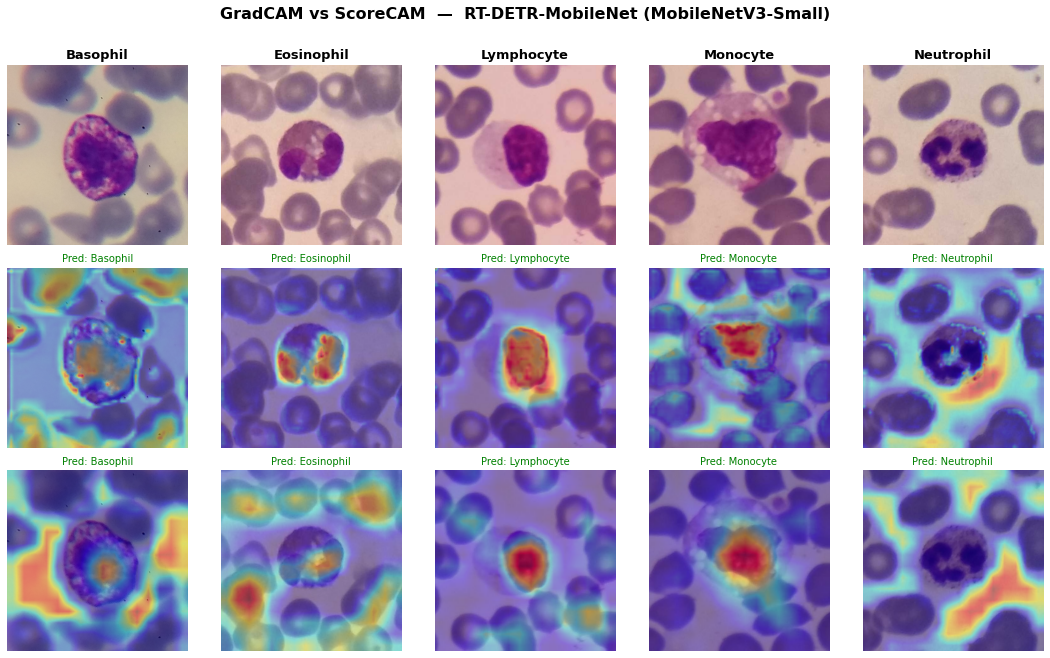

Saved: C:\D drive\mydata\MSML\GitHub\RT-DETR-Based-Explainable-CAD-System-for-Automated-Detection-and-Classification-of-White-Blood-Cells\output\results\gradcam_vs_scorecam_RT-DETR-MobileNet.png


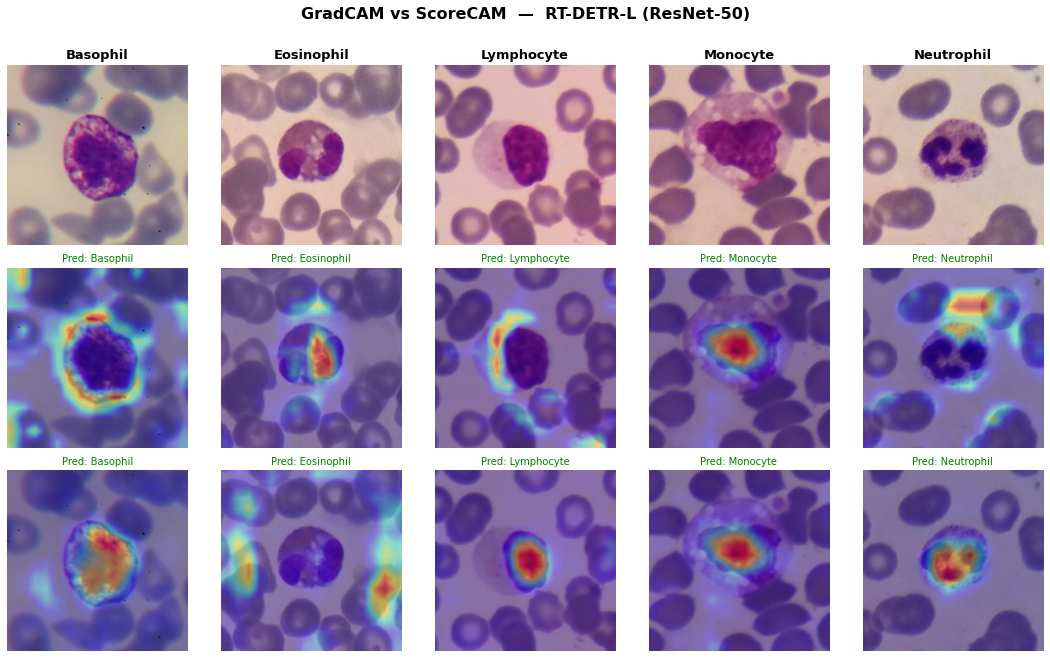

Saved: C:\D drive\mydata\MSML\GitHub\RT-DETR-Based-Explainable-CAD-System-for-Automated-Detection-and-Classification-of-White-Blood-Cells\output\results\gradcam_vs_scorecam_RT-DETR-L.png


In [17]:
# =============================================================================
# 13.4  GradCAM vs ScoreCAM -- Side-by-side Comparison (RT-DETR-L and MobileNet)
# =============================================================================
COMPARE_MODELS = ["RT-DETR-L", "RT-DETR-MobileNet"]

if gradcam_results and scorecam_results:
    for result in evaluation_results:
        bname    = result["model_name"]
        backbone = result["backbone"]

        if bname not in COMPARE_MODELS:
            continue
        if bname not in gradcam_results or bname not in scorecam_results:
            print(f"Skipping {bname}: results not available.")
            continue

        fig, axes = plt.subplots(3, NUM_CLASSES, figsize=(3 * NUM_CLASSES, 9))
        fig.suptitle(
            f"GradCAM vs ScoreCAM  —  {bname} ({backbone})",
            fontsize=16, fontweight="bold", y=1.01,
        )

        for i, cls_name in enumerate(CLASSES):
            g = gradcam_results[bname].get(cls_name)
            s = scorecam_results[bname].get(cls_name)

            # Row 0 - Original
            if g:
                axes[0, i].imshow(g[2])
            axes[0, i].set_title(cls_name, fontsize=13, fontweight="bold")
            axes[0, i].axis("off")
            if i == 0:
                axes[0, i].set_ylabel("Original", fontsize=12)

            # Row 1 - GradCAM
            if g and g[0] is not None:
                axes[1, i].imshow(g[0])
                pred  = ID2LABEL.get(g[3], "?")
                color = "green" if pred == cls_name else "red"
                axes[1, i].set_title(f"Pred: {pred}", fontsize=10, color=color)
            else:
                axes[1, i].text(0.5, 0.5, "N/A", ha="center", va="center",
                                transform=axes[1, i].transAxes, fontsize=14)
            axes[1, i].axis("off")
            if i == 0:
                axes[1, i].set_ylabel("GradCAM", fontsize=12)

            # Row 2 - ScoreCAM
            if s and s[0] is not None:
                axes[2, i].imshow(s[0])
                pred  = ID2LABEL.get(s[3], "?")
                color = "green" if pred == cls_name else "red"
                axes[2, i].set_title(f"Pred: {pred}", fontsize=10, color=color)
            else:
                axes[2, i].text(0.5, 0.5, "N/A", ha="center", va="center",
                                transform=axes[2, i].transAxes, fontsize=14)
            axes[2, i].axis("off")
            if i == 0:
                axes[2, i].set_ylabel("ScoreCAM", fontsize=12)

        plt.tight_layout()
        save_path = os.path.join(RESULTS_DIR, f"gradcam_vs_scorecam_{bname}.png")
        plt.savefig(save_path, dpi=80, bbox_inches="tight")
        plt.show()
        print(f"Saved: {save_path}")

else:
    print("Run the GradCAM and ScoreCAM cells above first.")
